# Fourier Transform

AI: The Fourier Transform is a mathematical tool used to convert a signal from the time (or spatial) domain into the frequency domain. It shows what frequencies are present in a signal and how strong they are.

**Key Ideas**

* Any complex signal can be expressed as a sum of simple sine and cosine waves.
* The Fourier Transform tells you which frequencies exist and their amplitudes.
* It is fundamental for analyzing signals that change over time or space.

**Why It’s Useful**

* Reveals hidden frequency information
* Simplifies analysis of signals and systems
* Helps filter noise, compress data, and analyze patterns

**Common Types**

* Fourier Series – For periodic signals
* Fourier Transform (FT) – For continuous, non‑periodic signals
* Discrete Fourier Transform (DFT) – For discrete data
* Fast Fourier Transform (FFT) – Efficient algorithm to compute the DFT

**Applications**

* Signal processing (audio, image, video)
* Communications and wireless systems
* Medical imaging (MRI, CT scans)
* Physics and engineering
* Data analysis and pattern recognition



In [1]:
import numpy as np
import matplotlib.pyplot as plt
# to integrate
from scipy import interpolate
import scipy.integrate as integrate

import pandas as pd

## Example 1: Intro
The following example provides a visual illustration of how the Fourier transform's integral measures whether a frequency is present in a particular function. 

Let's consider the next example to introduce the Fourier transformate. Let's $$f(t)=100\,e^{-\pi\,t^2}\,\cos(2\pi\,3t)$$ with $\omega_0=2\pi\,3$ Hz and frecuency $f=2\pi/\omega\approx 0.33$ Hz. Also consider $g(t,\omega)=\dfrac{1}{\sqrt{2\pi}}\,e^{-i\,2\pi\omega t}$ the continuos Fourier basis.

In [3]:
def f(t):
    return 100*np.exp(-np.pi*t**2)*np.cos(2*np.pi*3*t)

def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

Let's plot $f(t)\times g(t,w)$ for two frecuencies $\omega=\{3,5,...\}$ Hz and compute the integrals for the Re and Img in $x\,\epsilon\,[a,b]$. Notice that $\omega=3$ Hz is just the frecuency (actually $\omega_0=2\pi\omega$).

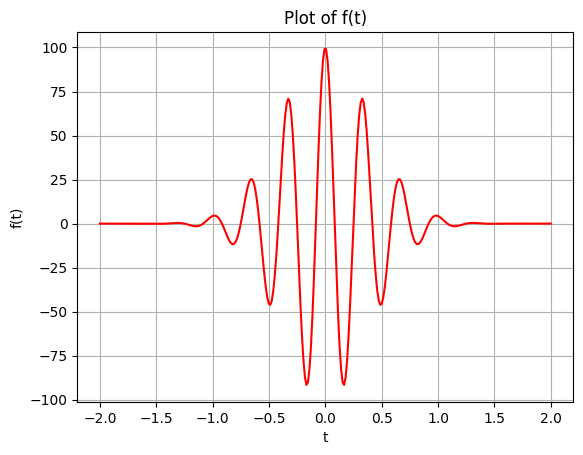

Integral of f(t) = -1.7449644601374992e-05


In [4]:
t = np.linspace(-2,2,300)

plt.plot(t, f(t),'r-')
plt.grid()
plt.title('Plot of f(t)')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()

A = integrate.quad(lambda t: f(t), t.min(), t.max())[0]
print('Integral of f(t) =', A)

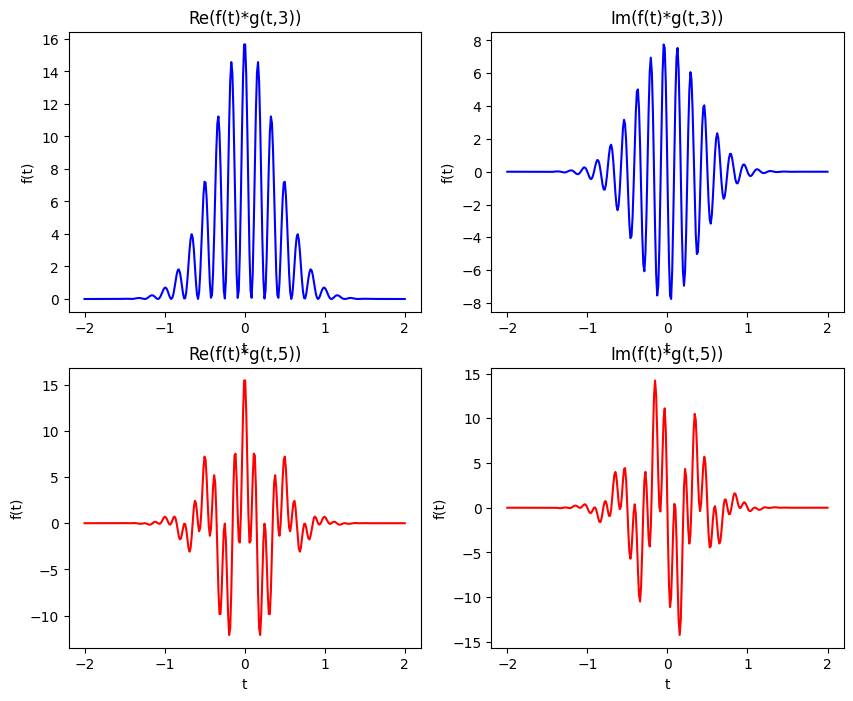

In [5]:
plt.figure(figsize=(10,8))
plt.subplot(2,2,1)
plt.plot(t, f(t)*g(t,3).real,'b-')
plt.title('Re(f(t)*g(t,3))')
plt.xlabel('t')
plt.ylabel('f(t)')

plt.subplot(2,2,2)
plt.plot(t, f(t)*g(t,3).imag,'b-')
plt.title('Im(f(t)*g(t,3))')
plt.xlabel('t')
plt.ylabel('f(t)')

plt.subplot(2,2,3)
plt.plot(t, f(t)*g(t,5).real,'r-')
plt.title('Re(f(t)*g(t,5))')
plt.xlabel('t')
plt.ylabel('f(t)')

plt.subplot(2,2,4)
plt.plot(t, f(t)*g(t,5).imag,'r-')
plt.title('Im(f(t)*g(t,5))')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.show()
plt.show()

In [6]:
ARew3 = integrate.quad(lambda t: f(t)*g(t,3).real, t.min(), t.max())[0]
AImw3 = integrate.quad(lambda t: f(t)*g(t,3).imag, t.min(), t.max())[0]
ARew5 = integrate.quad(lambda t: f(t)*g(t,5).real, t.min(), t.max())[0]
AImw5 = integrate.quad(lambda t: f(t)*g(t,5).imag, t.min(), t.max())[0]

print('Integral of Re(f(t)*g(t,3) =', ARew3)
print('Integral of Im(f(t)*g(t,3) =', AImw3)
print('Integral of Re(f(t)*g(t,5) =', ARew5)
print('Integral of Im(f(t)*g(t,5) =', AImw5)

Integral of Re(f(t)*g(t,3) = 7.95774244957613
Integral of Im(f(t)*g(t,3) = 0.0
Integral of Re(f(t)*g(t,5) = 2.52404027455323e-05
Integral of Im(f(t)*g(t,5) = 0.0


Notice that only the integral of the real part and with frecuency $\omega$ near the frecuecny of the $f(t)$ gives us an apreciable value. In this sense this procedure in a selector of frecuecnies.
The general situation is usually more complicated than this, but heuristically this is how **the Fourier transform measures how much of an individual frequency is present in a function ⁠$f(t)$**. 

In general, let's compute the integral for all (some) frecuencies and plot the result.

Fourier transform

\begin{equation}
\boxed{
F(\omega) = \dfrac{1}{\sqrt{2\pi}}\int_\infty f(t)e^{-2\,i\pi\omega} dt}
\end{equation}

In [5]:
# FRECUENCIES spectrum
w = np.linspace(-10,10,100)
df = []
for i in range(len(w)):
    ARew = integrate.quad(lambda t: f(t)*g(t,w[i]).real, t.min(), t.max())[0]
    AImw = integrate.quad(lambda t: f(t)*g(t,w[i]).imag, t.min(), t.max())[0]
    AMP = np.sqrt(ARew**2 + AImw**2)
    ANG = np.arctan2(AImw, ARew)
    df.append([w[i], ARew, AImw, AMP, ANG])

# DataFrame
df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])
df[:3]

,w,ReTw,ImTw,AMP,ANG
0,-10.00000,-4.384710e-07,0.0,4.384710e-07,3.141593
1,-9.79798,-6.827559e-07,0.0,6.827559e-07,3.141593
2,-9.59596,1.615035e-06,0.0,1.615035e-06,0.000000


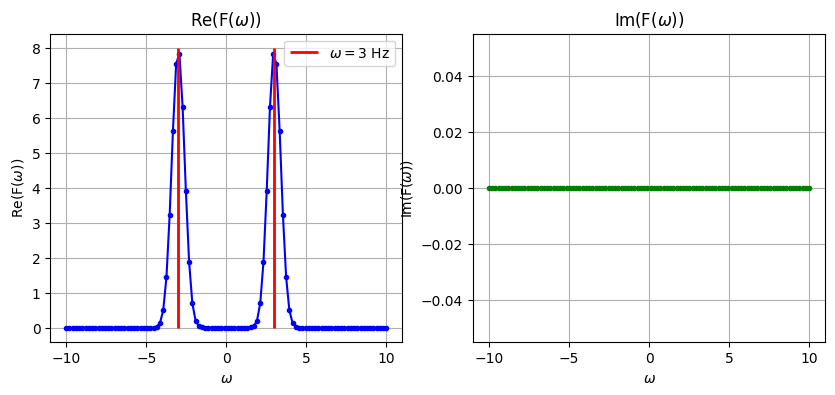

In [6]:
plt.figure(figsize=(10,4))
######## REAL ###########
plt.subplot(1,2,1)
plt.plot(df.w, df.ReTw,'b.')
plt.plot(df.w, df.ReTw,'b-')
plt.vlines(3,0, 8, color='r', lw=2, label='$\\omega=3$ Hz')
plt.vlines(-3,0,8, color='r', lw=2)
plt.title('Re(F($\\omega$))')
plt.xlabel('$\\omega$')
plt.legend(loc='best')
plt.grid()
plt.ylabel('Re(F($\\omega$))')
######### IMAG ##########
plt.subplot(1,2,2)
plt.plot(df.w, df.ImTw,'g.')
plt.title('Im(F($\\omega$))')
plt.xlabel('$\\omega$')
plt.ylabel('Im(F($\\omega$))')
plt.grid()
plt.show()

In this example we realize that the Fourier transform selec the frecuency $\omega = 3$ Hz over a wide range of frecuencies.

## Example 2: 

Let's consider two periodic functions with known frecuencies. Add the funtions and construc (guess) an algorith that recover thoose frecuencies from the combine signal.  

In [2]:
fs = 300 # Sampling frequency (Hz)
t = np.linspace(-3*np.pi, 3*np.pi, fs)

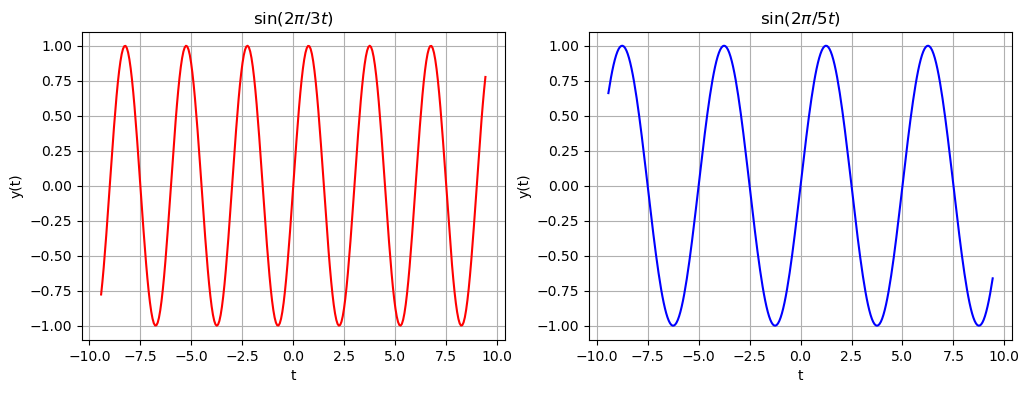

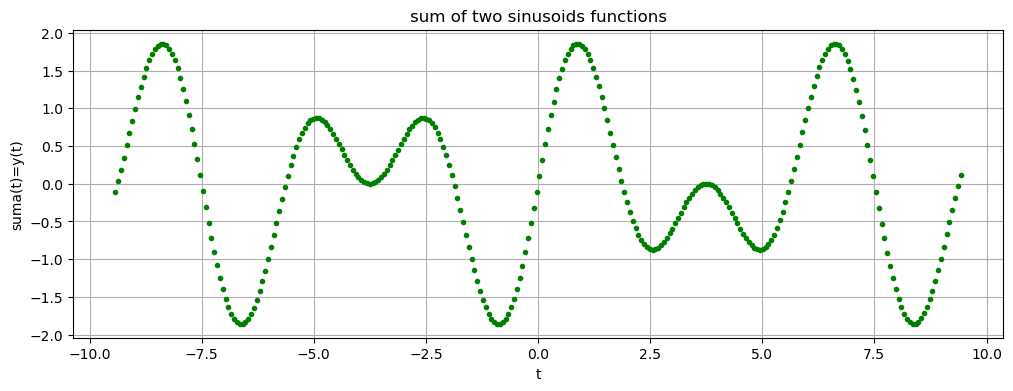

In [3]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(t, np.sin(2*np.pi/3*t),'r-')
plt.title(r'$\sin(2\pi/3t)$')
plt.grid()
plt.xlabel('t')
plt.ylabel('y(t)')
plt.subplot(1,2,2)
plt.plot(t, np.sin(2*np.pi/5*t),'b-')
plt.title(r'$\sin(2\pi/5t)$')
plt.grid()
plt.xlabel('t')
plt.ylabel('y(t)')
plt.show()

###### DATA: joint functions ##############
y = np.sin(2*np.pi/3*t)+np.sin(2*np.pi/5*t)
###########################################
plt.figure(figsize=(12,4))
plt.plot(t, y,'g.')
plt.title('sum of two sinusoids functions')
plt.xlabel('t')
plt.ylabel('suma(t)=y(t)')
plt.grid()
plt.show()

In [11]:
len(t)

300

First we need to interpolate the data in green.

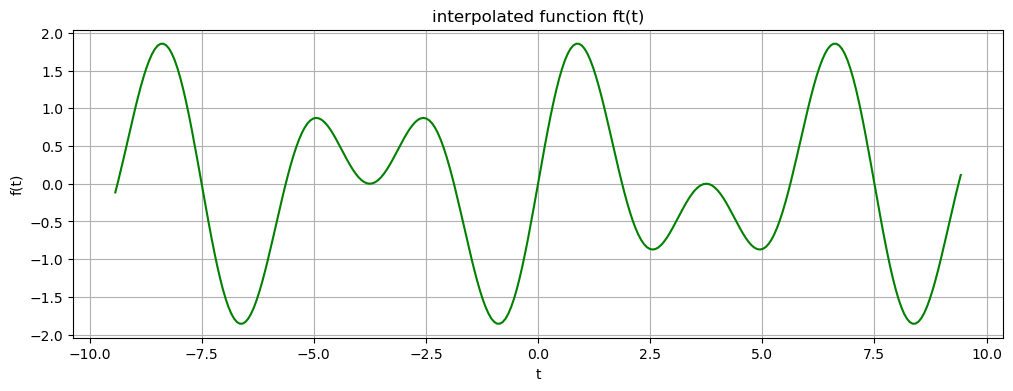

In [5]:
#### DATA in Green (t,y) ######

#Interpolate f(t) to integrate
from scipy import interpolate

f_interp = interpolate.interp1d(t, y, kind='cubic', fill_value='extrapolate')
ft = lambda t: f_interp(t) #Warning

# Plot the interpolated unknown function
plt.figure(figsize=(12,4))
plt.plot(t, ft(t),'g-')
plt.title('interpolated function ft(t)')
plt.xlabel('t')
plt.ylabel('f(t)')
plt.grid()
plt.show()

In [30]:
# Fourier continuos basis
def g(t,w):
    return 1./(2*np.pi)*np.exp(-1j*2*np.pi*w*t)

from scipy import interpolate

def FT(x,y):
    '''Integrate the Fourier Transform of f(t) at frequency w'''

    #Interpolate f(t) to integrate
    f_interp = interpolate.interp1d(x, y, kind='cubic', fill_value='extrapolate')
    ft = lambda t: f_interp(t)

    # range of t to integrate
    t = np.linspace(x.min(), x.max(), 400)

    # FRECUENCIES spectrum to looking for peaks
    w = np.linspace(0.1,1,100) 

    df = []
    for i in range(len(w)):
        ARew = integrate.quad(lambda t: ft(t)*g(t,w[i]).real, t.min(), t.max())[0]
        AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]
        AMP = np.sqrt(ARew**2 + AImw**2)
        ANG = np.arctan2(AImw, ARew)
        df.append([w[i], ARew, AImw, AMP, ANG])

    # DataFrame
    df = pd.DataFrame(df, columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])
    return df

In [31]:
df = pd.DataFrame(FT(t, y), columns=['w', 'ReTw', 'ImTw', 'AMP', 'ANG'])
df[:3]

/tmp/ipykernel_11861/175643644.py:23: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  AImw = integrate.quad(lambda t: ft(t)*g(t,w[i]).imag, t.min(), t.max())[0]


,w,ReTw,ImTw,AMP,ANG
0,0.100000,7.315925e-17,-0.058663,0.058663,-1.570796
1,0.109091,5.605234e-17,0.151934,0.151934,1.570796
2,0.118182,3.704004e-17,0.341908,0.341908,1.570796


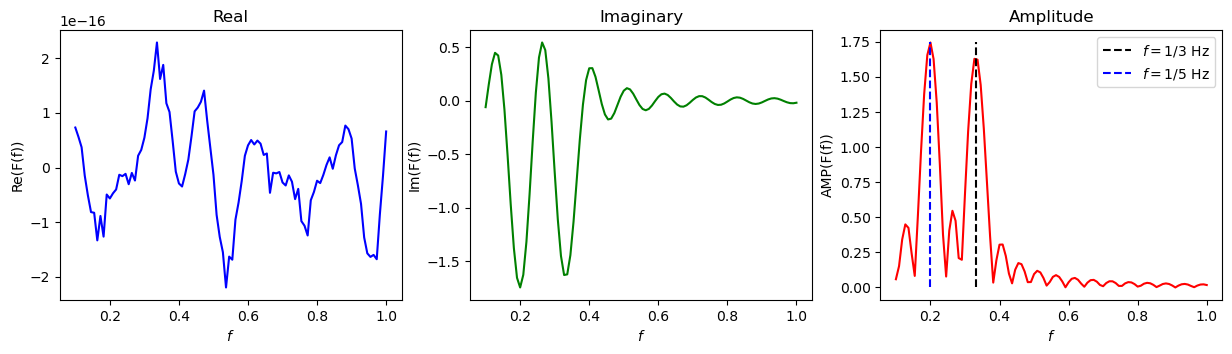

In [32]:
plt.figure(figsize=(15,3.5))
######## REAL ###########
plt.subplot(1,3,1)
plt.plot(df.w, df.ReTw,'b-')
plt.title('Real')
plt.xlabel('$f$')
plt.ylabel('Re(F(f))')
######### IMAG ##########
plt.subplot(1,3,2)
plt.plot(df.w, df.ImTw,'g-')
plt.title('Imaginary')
plt.xlabel('$f$')
plt.ylabel('Im(F(f))')
######### AMP ##########
plt.subplot(1,3,3)
plt.plot(df.w, df.AMP,'r-')
plt.vlines(1/3, 0, max(df.AMP), 'k', '--',label='$f=1/3$ Hz')
plt.vlines(1/5, 0, max(df.AMP), 'b', '--',label='$f=1/5$ Hz')
plt.title('Amplitude')
plt.xlabel('$f$')
plt.ylabel('AMP(F(f))')
plt.legend(loc='best')
plt.show()

# Fourier Transform using Numpy and scipy

In Python, the **Fast Fourier Transform** (FFT)—the practical algorithm for the Discrete Fourier Transform (DFT)—is most commonly implemented using the ``SciPy`` and ``NumPy`` libraries. 

Core Libraries

* SciPy (scipy.fft): Generally recommended for scientific applications as it is more feature-rich and often faster than the NumPy equivalent.
* NumPy (numpy.fft): A widely used alternative that is often already installed in many environments.
* OpenCV (cv2.dft): Specifically used for 2D Fourier transforms in image processing

In [33]:
from scipy.fft import fft, fftfreq

# 1. Sample the signal seen before (t,y)
signal = y
#fs = 100 # Sampling frequency (Hz) define in t

# 2. Compute the Fourier Transform
N = len(signal)
yf = fft(signal)
xf = fftfreq(N, 0.07) # Sampling period = 1/fs

/home/usuario/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/usuario/miniconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


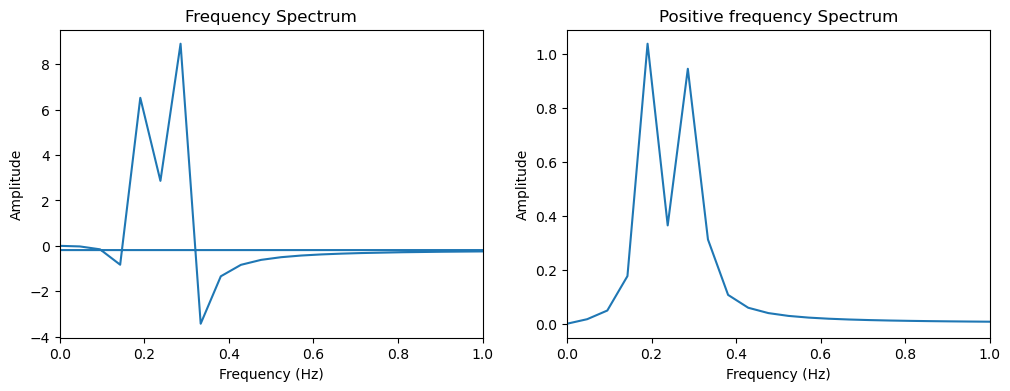

In [34]:
# 3. Plot the magnitude spectrum
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(xf, yf) 
plt.title('Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 1) 

plt.subplot(1,2,2)
plt.plot(xf[:N//4], 2.0/N * np.abs(yf[:N//4])) # Plot positive frequencies only
plt.title('Positive frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(0, 1) 
plt.show()

## Example of a chord musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Reading an MP3 signal in Python requires external libraries, as the standard library does not natively support MP3 decoding. The most common approach involves using PyDub or Librosa, both of which typically require FFmpeg to be installed on your system to handle the MP3 format.

**Recommended Libraries**

* PyDub: Best for general manipulation (slicing, merging, exporting) and extracting raw PCM data.
* Librosa: The standard for audio analysis and machine learning. It automatically resamples and normalizes the signal.
* pydub.playback: Simple tool for playing MP3 signals back once loaded.

**Option 1**: Using Librosa (Best for Signal Analysis)Librosa loads the MP3 and converts it into a NumPy array, which is ideal for mathematical processing.

In [18]:
# activar ambiente virtual
# source venv/activate
# pip install librosa

### **Reproduce an MP3 signal in Python**:

You can use high-level libraries like playsound for simple playback or Pygame and PyDub for more control over the audio stream.

1. Simplest Method: **playsound* The playsound module is the most straightforward, "one-line" solution for cross-platform playback.Installation: pip install playsound3 or new libraries.

2. Best for Games/Interactive Apps: **Pygame** The pygame.mixer module is ideal if you need to play music in the background or handle multiple sound effects.Installation: pip install pygameNote: Supports MP3 natively in version 2.0.2 and later.

In [37]:
from playsound3 import playsound
playsound('Nota_CM_piano.mp3')

### Read the signal

In [38]:
import librosa
import numpy as np

# Load the mp3 file
# sr=None preserves the original sampling rate; otherwise, it defaults to 22050 Hz
signal, sr = librosa.load('Nota_CM_piano.mp3', sr=None)

print(f"Sample Rate: {sr}")
print(f"Signal Shape: {signal.shape}")

Sample Rate: 44100
Signal Shape: (152064,)


El sample rate (o frecuencia de muestreo) es la cantidad de veces por segundo que se captura y mide una onda de sonido para convertirla de formato analógico a digital. Se mide en kiloHertz (kHz).

Plot the signal

Sample Rate: 44100
Signal Shape: (152064,)


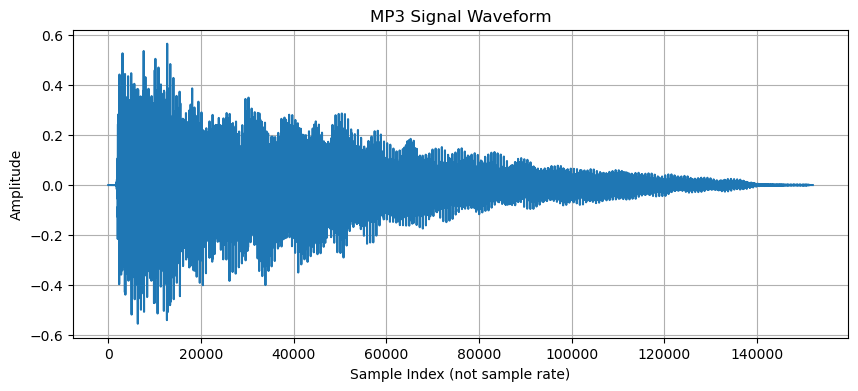

In [39]:
# Read the signal from the mp3 file
import librosa

print(f"Sample Rate: {sr}")
print(f"Signal Shape: {signal.shape}")

# Plot the signal
plt.figure(figsize=(10, 4))
plt.plot(signal)
plt.grid()
plt.title("MP3 Signal Waveform")
plt.xlabel("Sample Index (not sample rate)")
plt.ylabel("Amplitude")
plt.show()

### FFT 

Let's do the Fast fourier transform

El sample rate (o frecuencia de muestreo) es la cantidad de veces por segundo que se captura y mide una onda de sonido para convertirla de formato analógico a digital. Se mide en kiloHertz (kHz).

In [40]:
# Compute the Fourier Transform
N = len(signal)
print(f"Number of samples: {N}")
yf = fft(signal)
xf = fftfreq(N, 1/sr) # Frequency bins corresponding to the FFT output. WARNING

Number of samples: 152064


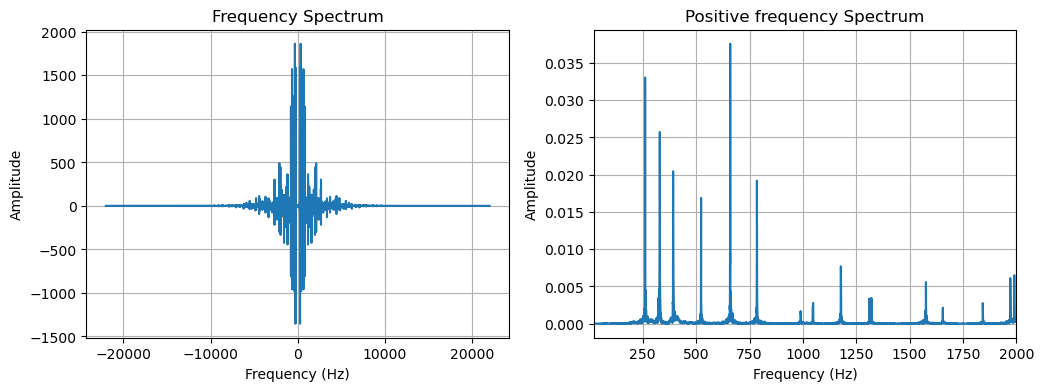

In [42]:
# 3. Plot the magnitude spectrum
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(xf, yf) 
plt.title('Frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.grid()
# *********************** positive frequencies *******************************
plt.subplot(1,2,2)
plt.plot(xf[:N//2], 2.0/N * np.abs(yf[:N//2])) # Plot positive frequencies only
plt.title('Positive frequency Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim(20, 2000) 
plt.grid()
plt.show()

The next line was generated with IA

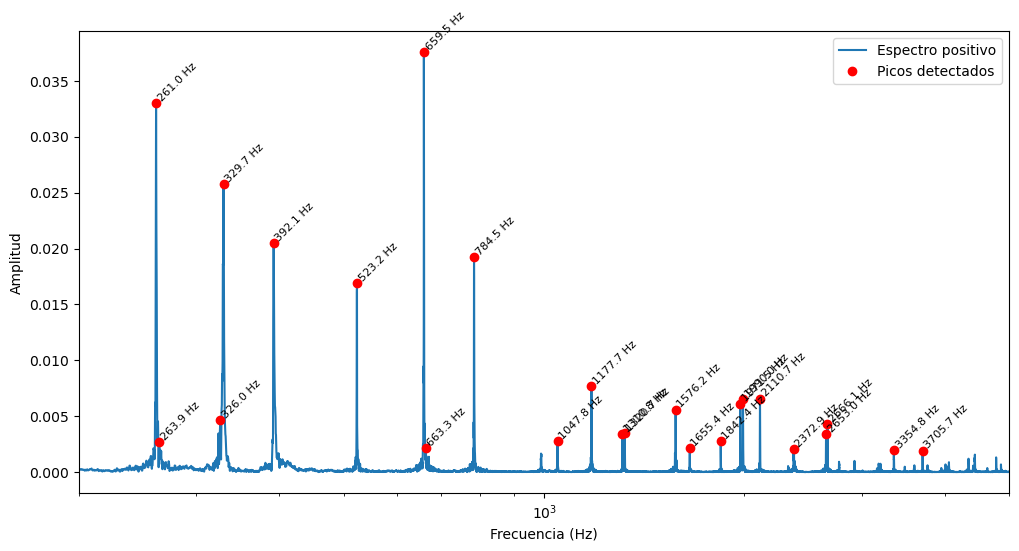

659.48 Hz -> 0.037576
261.01 Hz -> 0.033041
329.74 Hz -> 0.025733
392.09 Hz -> 0.020458
784.48 Hz -> 0.019204
523.18 Hz -> 0.016880
1177.73 Hz -> 0.007699
2110.69 Hz -> 0.006563
1990.04 Hz -> 0.006517
1971.48 Hz -> 0.006119


In [43]:
from scipy.signal import find_peaks

xf_pos = xf[:N // 2]
mag = 2.0 / N * np.abs(yf[:N // 2])

peaks, props = find_peaks(mag, height=np.max(mag) * 0.05, prominence=np.max(mag) * 0.02, distance=10)

plt.figure(figsize=(12, 6))
plt.semilogx(xf_pos, mag, label='Espectro positivo')
plt.plot(xf_pos[peaks], mag[peaks], 'ro', label='Picos detectados')
for f, a in zip(xf_pos[peaks], mag[peaks]):
    plt.text(f, a, f'{f:.1f} Hz', fontsize=8, rotation=45, va='bottom')
plt.xlim(200, 5E3)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.legend()
plt.show()

peak_freqs = xf_pos[peaks]
peak_amps = mag[peaks]

# Mostrar los picos ordenados por amplitud descendente
order = np.argsort(peak_amps)[::-1]
for i in order[:10]:
    print(f'{peak_freqs[i]:.2f} Hz -> {peak_amps[i]:.6f}')